In [1]:
# core Python / Data Handling
import numpy as np
import pandas as pd
import re, string, unicodedata
from string import punctuation
from collections import Counter
from warnings import filterwarnings

# visualization
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px
from wordcloud import WordCloud, STOPWORDS

# sklearn
from sklearn.preprocessing import LabelBinarizer
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from sklearn import set_config
set_config(print_changed_only=False)

# tensorFlow / Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, LSTM, Dropout
from tensorflow.keras.callbacks import ReduceLROnPlateau
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# nlp / text processing
import nltk
from nltk.corpus import stopwords, wordnet
from nltk.stem.porter import PorterStemmer
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize, sent_tokenize
from nltk import pos_tag
from textblob import Word

# nltk resources download
nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)
nltk.download('omw-1.4', quiet=True)


from termcolor import colored

filterwarnings('ignore')


In [3]:
!wget -q -O glove.twitter.27B.100d.txt \
  "https://github.com/rastogin1216/Portfolio_Projects/releases/download/v1.0/glove.twitter.27B.100d.txt"

FAKE_URL = "https://github.com/rastogin1216/Portfolio_Projects/releases/download/v1.0/Fake.csv"
TRUE_URL = "https://github.com/rastogin1216/Portfolio_Projects/releases/download/v1.0/True.csv"

fake_news = pd.read_csv(FAKE_URL)
real_news = pd.read_csv(TRUE_URL)

In [4]:
real_news.head()

,title,text,subject,date
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017"
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017"
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017"
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017"
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017"


In [5]:
fake_news.head()

,title,text,subject,date
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017"
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017"
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017"
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017"
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017"


In [6]:
real_news['news_class'], fake_news['news_class'] = 1, 0

news = pd.concat([real_news, fake_news])
news.head()

,title,text,subject,date,news_class
0,"As U.S. budget fight looms, Republicans flip t...",WASHINGTON (Reuters) - The head of a conservat...,politicsNews,"December 31, 2017",1
1,U.S. military to accept transgender recruits o...,WASHINGTON (Reuters) - Transgender people will...,politicsNews,"December 29, 2017",1
2,Senior U.S. Republican senator: 'Let Mr. Muell...,WASHINGTON (Reuters) - The special counsel inv...,politicsNews,"December 31, 2017",1
3,FBI Russia probe helped by Australian diplomat...,WASHINGTON (Reuters) - Trump campaign adviser ...,politicsNews,"December 30, 2017",1
4,Trump wants Postal Service to charge 'much mor...,SEATTLE/WASHINGTON (Reuters) - President Donal...,politicsNews,"December 29, 2017",1


In [7]:
news.info(memory_usage=True, verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 44898 entries, 0 to 23480
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   title       44898 non-null  object
 1   text        44898 non-null  object
 2   subject     44898 non-null  object
 3   date        44898 non-null  object
 4   news_class  44898 non-null  int64 
dtypes: int64(1), object(4)
memory usage: 2.1+ MB


In [8]:
news.duplicated().sum()
news.drop_duplicates(inplace = True)

In [9]:
news.groupby('news_class').count()


,title,text,subject,date
news_class,,,,
0,23478,23478,23478,23478
1,21211,21211,21211,21211


In [10]:
news.isnull().sum()

,0
title,0
text,0
subject,0
date,0
news_class,0


In [11]:
news['subject'].value_counts()

,count
subject,
politicsNews,11220
worldnews,9991
News,9050
politics,6838
left-news,4459
Government News,1570
US_News,783
Middle-east,778


In [12]:
news['subject'] = news['subject'].str.lower().str.replace('_', ' ').str.strip()
mapping = {
    "politicsnews": "politics",
    "government news": "politics",
    "us news": "politics",
    "left-news": "politics_left",
    "worldnews": "world",
    "middle-east": "world",
    "news": "general"
}

news['subject'] = news['subject'].map(mapping)
news['subject'].value_counts()

,count
subject,
politics,13573
world,10769
general,9050
politics_left,4459


In [13]:
news['title'].count()

np.int64(44689)

# **Exploratory Data Analysis**


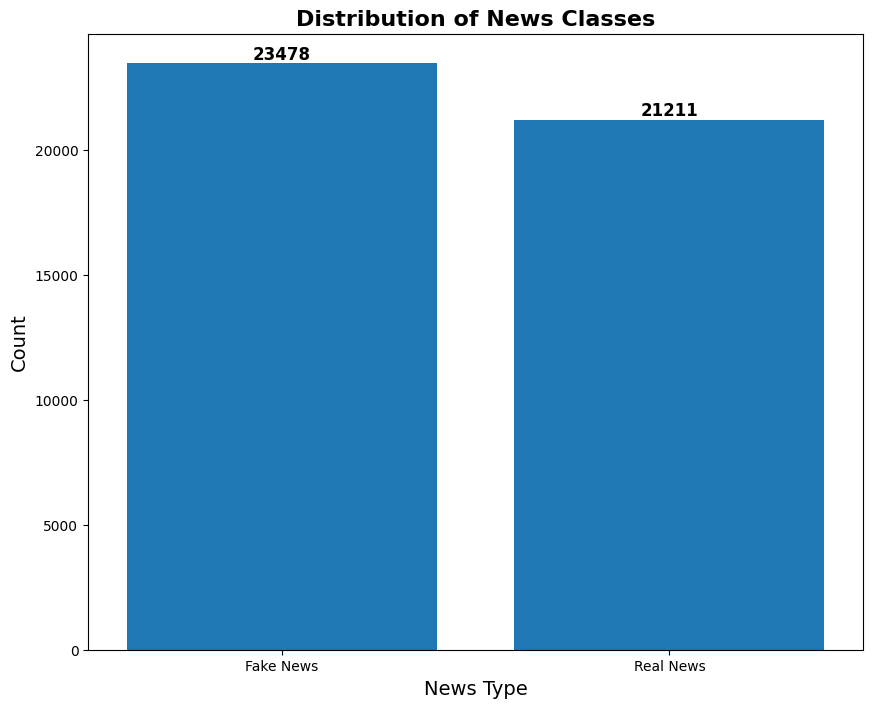

In [14]:
plt.figure(figsize=(10, 8), clear=True, facecolor='white')

# Map 0/1 to labels
class_labels = {0: "Fake News", 1: "Real News"}
counts = news['news_class'].value_counts().sort_index()
counts.index = counts.index.map(class_labels)

ax = sns.barplot(x=counts.index, y=counts.values, saturation=1)

# Add value labels above bars
for i, value in enumerate(counts.values):
    ax.text(i, value + 0.5, str(value), ha='center', va='bottom', fontsize=12, fontweight='bold')

# Labels and title
ax.set_title("Distribution of News Classes", fontsize=16, fontweight='bold')
ax.set_xlabel("News Type", fontsize=14)
ax.set_ylabel("Count", fontsize=14)

plt.show()


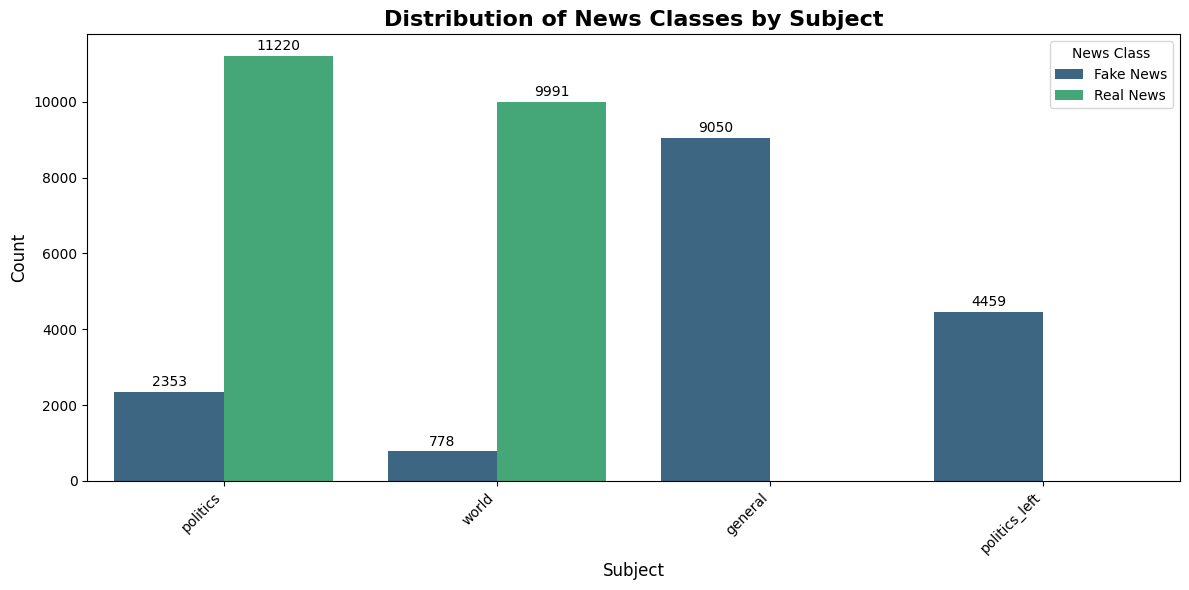

In [15]:
news = news.loc[:, ~news.columns.duplicated()].copy()

news['news_class'] = news['news_class'].astype(int)
news['news_class_label'] = news['news_class'].map({0: 'Fake News', 1: 'Real News'})


# aggregate counts per subject x class
counts = (
    news.groupby(['subject', 'news_class_label'])
        .size()
        .reset_index(name='count')
)

# order subjects by total volume
subject_order = (
    counts.groupby('subject')['count']
          .sum()
          .sort_values(ascending=False)
          .index
)


plt.figure(figsize=(12, 6), clear=True, facecolor='white')
ax = sns.barplot(
    data=counts,
    x='subject',
    y='count',
    hue='news_class_label',
    order=subject_order,
    palette='viridis'
)

# tile and axes
ax.set_title('Distribution of News Classes by Subject', fontsize=16, fontweight='bold')
ax.set_xlabel('Subject', fontsize=12)
ax.set_ylabel('Count', fontsize=12)
plt.xticks(rotation=45, ha='right')

# bar labels
for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=2)

# legend
ax.legend(title='News Class', loc='upper right')

plt.tight_layout()
plt.show()

# Data Preprocessing


In [16]:
news['text'] = news['text'] + " " + news['title']

news.drop(['title', 'date', 'subject','news_class_label' ], axis =1, inplace=True )
news.head()

,text,news_class
0,WASHINGTON (Reuters) - The head of a conservat...,1
1,WASHINGTON (Reuters) - Transgender people will...,1
2,WASHINGTON (Reuters) - The special counsel inv...,1
3,WASHINGTON (Reuters) - Trump campaign adviser ...,1
4,SEATTLE/WASHINGTON (Reuters) - President Donal...,1


In [17]:
news['text'] = news['text'].apply(lambda x : " ".join(x.lower() for x in x.split() ) )
news.head()

,text,news_class
0,washington (reuters) - the head of a conservat...,1
1,washington (reuters) - transgender people will...,1
2,washington (reuters) - the special counsel inv...,1
3,washington (reuters) - trump campaign adviser ...,1
4,seattle/washington (reuters) - president donal...,1


In [18]:
news['text'] = news['text'].str.replace('[^\w\s]','')
news['text'] = news['text'].str.replace('\d', '' )

In [19]:
# remove stopwords + punctuation
stop_words = set(stopwords.words('english'))
punctuation = list(string.punctuation)

stop_words.update(punctuation)

news['text'] = news['text'].apply(lambda x: " ".join(x for x in x.split() if x not in stop_words ) )

news.head()


,text,news_class
0,washington (reuters) head conservative republi...,1
1,washington (reuters) transgender people allowe...,1
2,washington (reuters) special counsel investiga...,1
3,washington (reuters) trump campaign adviser ge...,1
4,seattle/washington (reuters) president donald ...,1


In [20]:
# lemmatize words
news['text'] = news['text'].apply(lambda x : " ".join([Word(word).lemmatize() for word in x.split()]) )

In [21]:
# removes URLs
news['text'] = news['text'].apply(lambda x: re.sub(r'http\S+', '', x))

In [22]:
news.head(n = 10).style.background_gradient(cmap = 'summer')

,text,news_class
0,"washington (reuters) head conservative republican faction u.s. congress, voted month huge expansion national debt pay tax cuts, called “fiscal conservative” sunday urged budget restraint 2018. keeping sharp pivot way among republicans, u.s. representative mark meadows, speaking cbs’ “face nation,” drew hard line federal spending, lawmaker bracing battle january. return holiday wednesday, lawmaker begin trying pas federal budget fight likely linked issues, immigration policy, even november congressional election campaign approach republican seek keep control congress. president donald trump republican want big budget increase military spending, democrat also want proportional increase non-defense “discretionary” spending program support education, scientific research, infrastructure, public health environmental protection. “the (trump) administration already willing say: ‘we’re going increase non-defense discretionary spending ... 7 percent,’” meadows, chairman small influential house freedom caucus, said program. “now, democrat saying that’s enough, need give government pay raise 10 11 percent. fiscal conservative, don’t see rationale is. ... eventually run people’s money,” said. meadow among republican voted late december party’s debt-financed tax overhaul, expected balloon federal budget deficit add $1.5 trillion 10 year $20 trillion national debt. “it’s interesting hear mark talk fiscal responsibility,” democratic u.s. representative joseph crowley said cbs. crowley said republican tax bill would require united state borrow $1.5 trillion, paid future generations, finance tax cut corporation rich. “this one least ... fiscally responsible bill we’ve ever seen passed history house representatives. think we’re going paying many, many year come,” crowley said. republican insist tax package, biggest u.s. tax overhaul 30 years, boost economy job growth. house speaker paul ryan, also supported tax bill, recently went meadows, making clear radio interview welfare “entitlement reform,” party often call it, would top republican priority 2018. republican parlance, “entitlement” program mean food stamps, housing assistance, medicare medicaid health insurance elderly, poor disabled, well program created washington assist needy. democrat seized ryan’s early december remarks, saying showed republican would try pay tax overhaul seeking spending cut social programs. goal house republican may take back seat senate, vote democrat needed approve budget prevent government shutdown. democrat use leverage senate, republican narrowly control, defend discretionary non-defense program social spending, tackling issue “dreamers,” people brought illegally country children. trump september put march 2018 expiration date deferred action childhood arrivals, daca, program, protects young immigrant deportation provides work permits. president said recent twitter message want funding proposed mexican border wall immigration law change exchange agreeing help dreamers. representative debbie dingell told cbs favor linking issue policy objectives, wall funding. “we need daca clean,” said. wednesday, trump aide meet congressional leader discus issues. followed weekend strategy session trump republican leader jan. 6 7, white house said. trump also scheduled meet sunday florida republican governor rick scott, want emergency aid. house passed $81 billion aid package hurricane florida, texas puerto rico, wildfire california. package far exceeded $44 billion requested trump administration. senate yet voted aid. u.s. budget fight looms, republican flip fiscal script",1
1,"washington (reuters) transgender people allowed first time enlist u.s. military starting monday ordered federal courts, pentagon said friday, president donald trump’s administration decided appeal ruling blocked transgender ban. two federal appeal courts, one washington one virginia, last week rejected administration’s request put hold order lower court judge requiring military begi

Text(0.5, 1.0, 'Distribution of Text length for Real News')

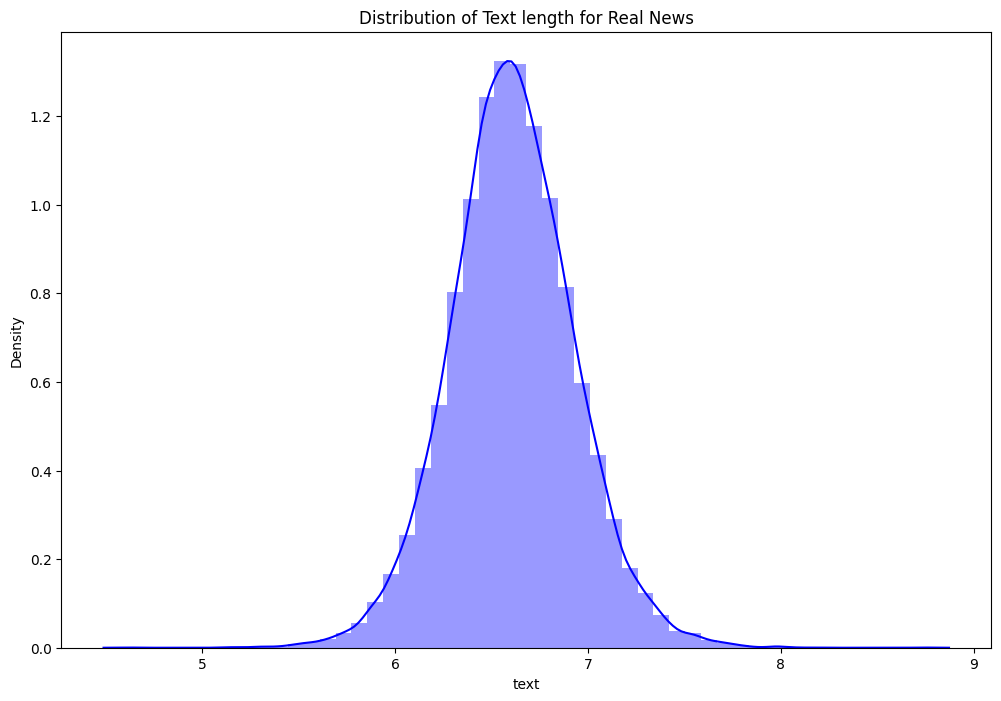

In [23]:
fix, ax = plt.subplots(figsize = (12, 8))

text_words = news[news['news_class'] == 1 ]['text'].str.split().apply(lambda x : [len(i) for i in x])

sns.distplot(text_words.map(lambda x : np.mean(x)), color = 'blue', ax = ax ).set_title('Distribution of Text length for Real News')

Text(0.5, 1.0, 'Distribution of Text length for Fake News')

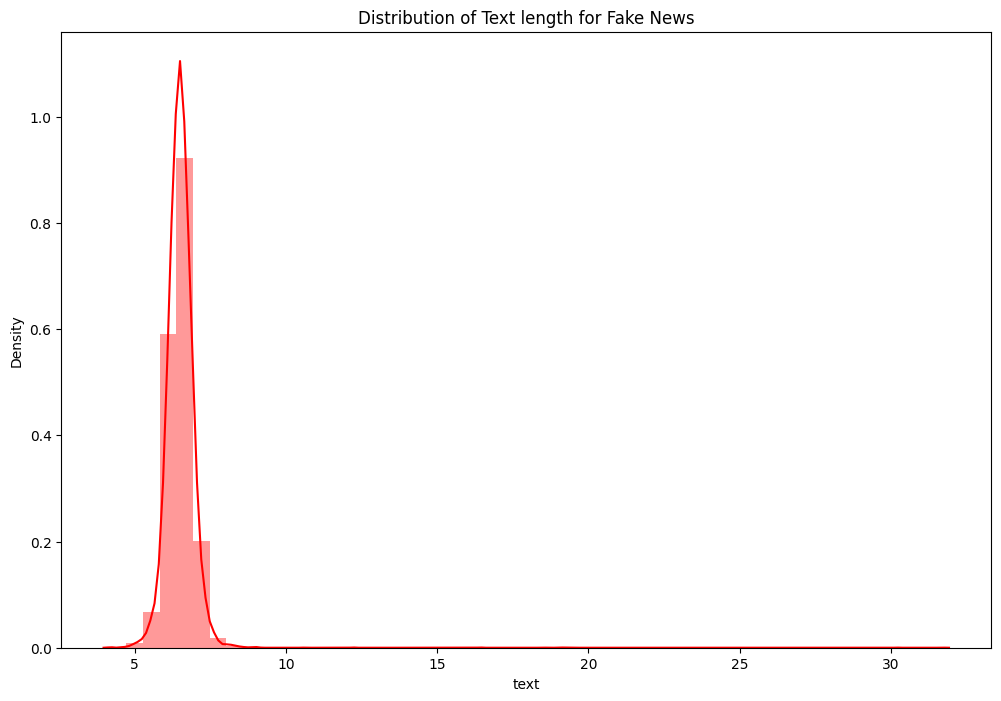

In [24]:
fix, ax = plt.subplots(figsize = (12, 8))

text_words = news[news['news_class'] == 0 ]['text'].str.split().apply(lambda x : [len(i) for i in x])

sns.distplot(text_words.map(lambda x : np.mean(x)), color = 'red', ax = ax ).set_title('Distribution of Text length for Fake News')

## Data Preparation

In [25]:
x = news['text']
y = news['news_class']

train_x, test_x, train_y, test_y = train_test_split(x, y, test_size=0.25, shuffle = True, random_state=11 )

In [26]:
print(train_x.shape, test_x.shape)

(33516,) (11173,)


In [27]:
tokenizer = Tokenizer(num_words=10000)
tokenizer.fit_on_texts(train_x)

tokenized_train = tokenizer.texts_to_sequences(train_x)
tokenized_test = tokenizer.texts_to_sequences(test_x)

In [31]:
def get_coefs(word, *arr):
    return word, np.asarray(arr, dtype="float32")

# map word to vector
with open("glove.twitter.27B.100d.txt", "r", encoding="utf8") as f:
    embeddings_index = dict(get_coefs(*g.rstrip().rsplit(" ")) for g in f)

print(f"Loaded {len(embeddings_index)} word vectors.")

# display sample vectors
for word in list(embeddings_index.keys())[:5]:
    print(word, embeddings_index[word][:10])  # show first 10 dims only


Loaded 1193514 word vectors.
<user> [0.63006  0.65177  0.25545  0.018593 0.043094 0.047194 0.23218  0.11613
 0.17371  0.40487 ]
. [ 0.18205  -0.048483  0.23966   0.32099  -0.27002   0.70431  -0.21257
  0.235     0.090142  0.82141 ]
: [ 1.0674    0.45716   0.51463   0.26679   0.19921  -0.072329  0.078455
  0.19458   0.42281   0.1928  ]
rt [0.6047   0.89542  0.27923  0.033489 0.15873  0.18522  0.30722  0.47445
 0.44484  0.7045  ]
, [ 0.32299  -0.58293  -0.23327   0.34409  -0.56934   1.3211   -0.086267
  0.20526   0.5832    0.47516 ]


In [32]:
print(f"Vocabulary size: {len(tokenizer.word_index)}")
print(list(tokenizer.word_index.items())[:10])

Vocabulary size: 124224
[('trump', 1), ('said', 2), ('u', 3), ('president', 4), ('s', 5), ('would', 6), ('state', 7), ('people', 8), ('”', 9), ('republican', 10)]


In [33]:
# summarize embeddings: mean, std, size, and vocab limit
all_vecs = list(embeddings_index.values())
embedding_mean = np.mean([np.mean(v) for v in all_vecs])
embedding_std = np.mean([np.std(v) for v in all_vecs])
embedding_size = len(all_vecs[0])
word_index = tokenizer.word_index
nb_word = min(10000, len(word_index) )

In [34]:
# build embedding matrix with GloVe vectors
embedding_matrix = np.random.normal(embedding_mean, embedding_std, (nb_word, embedding_size) )

for word, i in word_index.items():
    if i >= 10000:
        continue
    embedding_vector = embeddings_index.get(word)
    if embedding_vector is not None:
        embedding_matrix[i] = embedding_vector

In [36]:
# reduce LR if val_accuracy plateaus
lr_reduce = ReduceLROnPlateau(monitor = 'val_accuracy', patience = 2, factor = 0.5, min_lr = 0.00001 )

In [37]:
MAX_LEN = 300

# input layer: token IDs
inputs = tf.keras.Input(shape=(MAX_LEN,), dtype='int32', name='tokens')

# pretrained embeddings (GloVe), frozen
x = tf.keras.layers.Embedding(
    input_dim=embedding_matrix.shape[0],
    output_dim=embedding_matrix.shape[1],
    weights=[embedding_matrix],
    mask_zero=True,
    trainable=False,
    name='embed'
)(inputs)

# stacked LSTMs for sequence modeling
x = tf.keras.layers.LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.0, use_cudnn=False)(x)
x = tf.keras.layers.LSTM(64,  dropout=0.15, recurrent_dropout=0.0, use_cudnn=False)(x)

# dense layers for classification
x = tf.keras.layers.Dense(32, activation='relu', name='dense1')(x)
outputs = tf.keras.layers.Dense(1, activation='sigmoid', name='out')(x)

model = tf.keras.Model(inputs, outputs, name='fake_news_lstm')


model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

Model: "fake_news_lstm"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ tokens (InputLayer) │ (None, 300)       │          0 │ -                 │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ embed (Embedding)   │ (None, 300, 100)  │  1,000,000 │ tokens[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ not_equal           │ (None, 300)       │          0 │ tokens[0][0]      │
│ (NotEqual)          │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm (LSTM)         │ (None, 300, 128)  │    117,248 │ embed[0][0],      │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ lstm_1 (LSTM)       │ (None, 64)        │     49,408 │ lstm[0][0],       │
│                     │                   │            │ not_equal[0][0]   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense1 (Dense)      │ (None, 32)        │      2,080 │ lstm_1[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ out (Dense)         │ (None, 1)         │         33 │ dense1[0][0]      │
└─────────────────────┴───────────────────┴────────────┴───────────────────┘

 Total params: 1,168,769 (4.46 MB)

 Trainable params: 168,769 (659.25 KB)

 Non-trainable params: 1,000,000 (3.81 MB)

In [38]:
X_train = pad_sequences(tokenized_train, maxlen=MAX_LEN, padding='post', truncating='post')
X_test  = pad_sequences(tokenized_test,  maxlen=MAX_LEN, padding='post', truncating='post')

# labels to numeric arrays
y_train = np.asarray(train_y).astype('float32').reshape(-1, )
y_test  = np.asarray(test_y).astype('float32').reshape(-1, )


# fit
history = model.fit(
    X_train, y_train,
    batch_size=128,
    validation_data=(X_test, y_test),
    epochs=10,
    callbacks=[lr_reduce]
)

Epoch 1/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 36s 104ms/step - accuracy: 0.8323 - loss: 0.3663 - val_accuracy: 0.9519 - val_loss: 0.1466 - learning_rate: 0.0010
Epoch 2/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 28s 74ms/step - accuracy: 0.9390 - loss: 0.1686 - val_accuracy: 0.9256 - val_loss: 0.1896 - learning_rate: 0.0010
Epoch 3/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - accuracy: 0.9288 - loss: 0.1815 - val_accuracy: 0.9344 - val_loss: 0.1767 - learning_rate: 0.0010
Epoch 4/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 19s 74ms/step - accuracy: 0.9658 - loss: 0.1002 - val_accuracy: 0.9824 - val_loss: 0.0491 - learning_rate: 5.0000e-04
Epoch 5/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 19s 74ms/step - accuracy: 0.9814 - loss: 0.0570 - val_accuracy: 0.9856 - val_loss: 0.0395 - learning_rate: 5.0000e-04
Epoch 6/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 19s 73ms/step - accuracy: 0.9868 - loss: 0.0423 - val_accuracy: 0.9910 - val_loss: 0.0325 - learning_rate: 5.0000e-04
Epoch 7/10
262/262 ━━━━━━━━━━━━━━━━━━━━ 21s 74ms/step - accurac

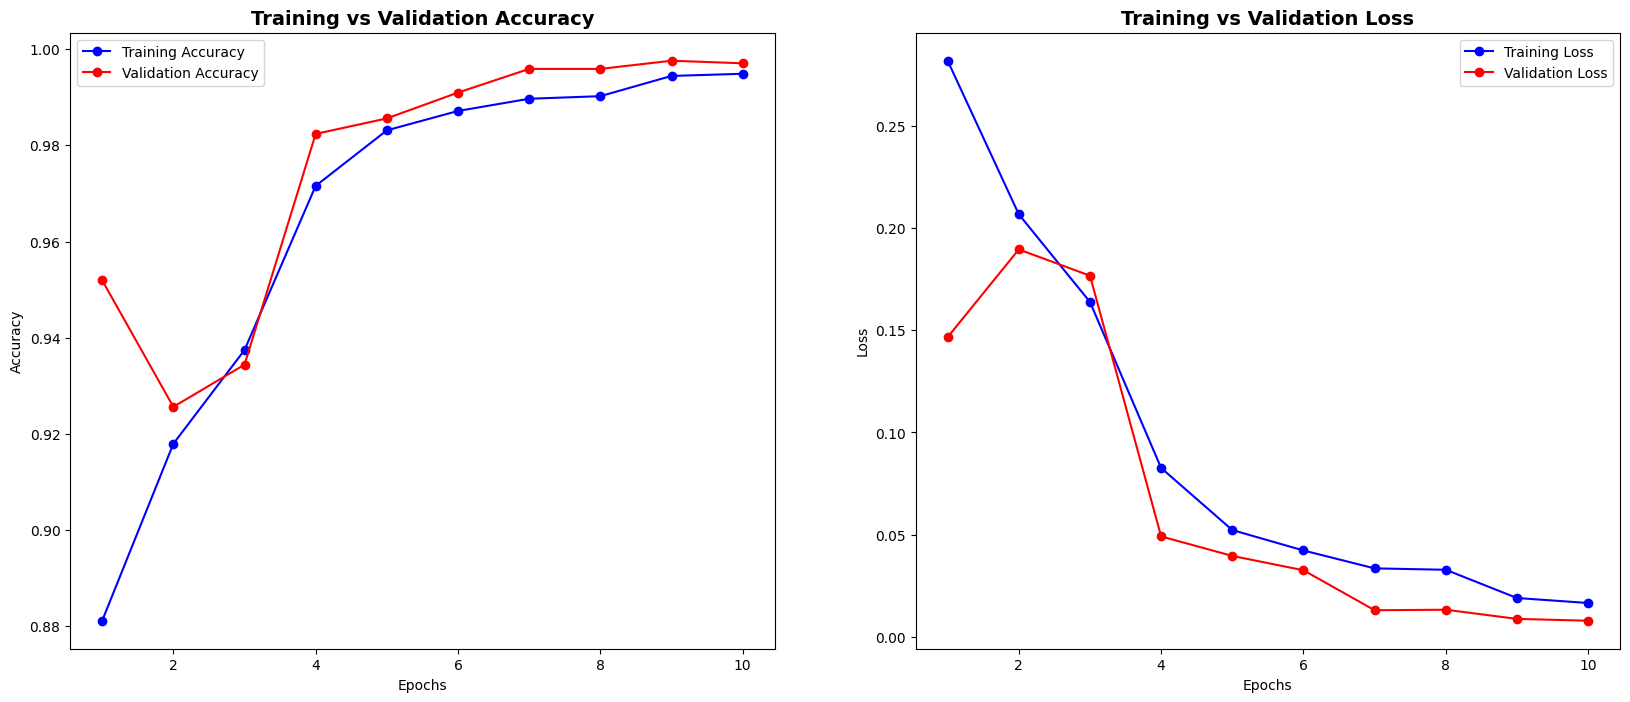

In [40]:
epochs = range(1, len(history.history['accuracy']) + 1)

train_acc = history.history['accuracy']
val_acc   = history.history['val_accuracy']
train_loss = history.history['loss']
val_loss   = history.history['val_loss']

fig, ax = plt.subplots(1, 2, figsize=(20, 8))

# accuracy
ax[0].plot(epochs, train_acc, 'bo-', label='Training Accuracy')
ax[0].plot(epochs, val_acc, 'ro-', label='Validation Accuracy')
ax[0].set_title('Training vs Validation Accuracy', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Accuracy')
ax[0].legend()

# loss
ax[1].plot(epochs, train_loss, 'bo-', label='Training Loss')
ax[1].plot(epochs, val_loss, 'ro-', label='Validation Loss')
ax[1].set_title('Training vs Validation Loss', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Loss')
ax[1].legend()

plt.show()

350/350 ━━━━━━━━━━━━━━━━━━━━ 8s 16ms/step
              precision    recall  f1-score   support

         0.0     0.9969    0.9974    0.9971      5771
         1.0     0.9972    0.9967    0.9969      5402

    accuracy                         0.9970     11173
   macro avg     0.9971    0.9970    0.9970     11173
weighted avg     0.9970    0.9970    0.9970     11173



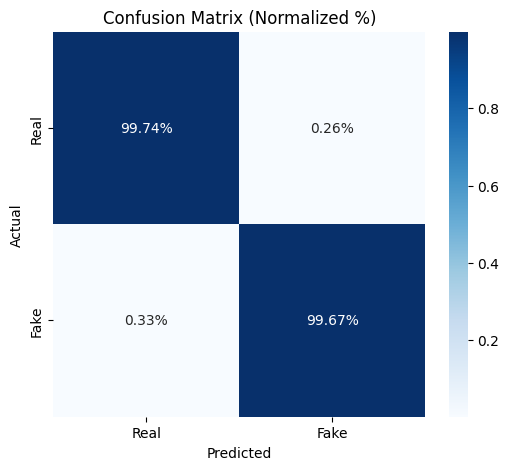

In [41]:
pred_probs = model.predict(X_test)

classes_pred = (pred_probs > 0.5).astype("int32").flatten()

print(classification_report(y_test, classes_pred, digits=4))

cm = confusion_matrix(y_test, classes_pred)
cm_norm = cm.astype("float") / cm.sum(axis=1)[:, np.newaxis]

plt.figure(figsize=(6,5))
sns.heatmap(cm_norm, annot=True, fmt=".2%", cmap="Blues",
            xticklabels=["Real", "Fake"],
            yticklabels=["Real", "Fake"])
plt.title("Confusion Matrix (Normalized %)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()